# [LAB 07] 12-1. 교차분석의 이해
## # 연습문제

In [1]:
from hossam import load_data
from helpers import *

from pandas import DataFrame

📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: 0.5.19


In [2]:
origin = load_data('wage')
origin.head()

📚 경제 및 노동 시장에 관련된 정보를 담고 있는 데이터셋(출처: ADsP 기출문제)

    field       description
--  ----------  ------------------
 0  year        년도
 1  age         나이
 2  maritl      결혼여부
 3  race        근로자의 인종
 4  education   교육수준
 5  region      지역
 6  jobclass    직군
 7  health      건상상태
 8  health_ins  건강보험 가입 여부
 9  logwage     임금(로그값)
10  wage        임금



,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318,75.043
1,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255,70.476
2,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875,130.982
3,2003,43,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041,154.685
4,2005,50,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318,75.043


In [3]:
df = origin.copy()
for c in ['maritl', 'race', 'education', 'region', 'jobclass', 'health', 'health_ins']:
    df[c] = df[c].str.replace(r'^\d+\.\s*', '', regex=True)

df.head()

,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,Never Married,White,< HS Grad,Middle Atlantic,Industrial,<=Good,No,4.318,75.043
1,2004,24,Never Married,White,College Grad,Middle Atlantic,Information,>=Very Good,No,4.255,70.476
2,2003,45,Married,White,Some College,Middle Atlantic,Industrial,<=Good,Yes,4.875,130.982
3,2003,43,Married,Asian,College Grad,Middle Atlantic,Information,>=Very Good,Yes,5.041,154.685
4,2005,50,Divorced,White,HS Grad,Middle Atlantic,Information,<=Good,Yes,4.318,75.043


#### 문제 1. 절반씩 일하나요? Industrial 직군과 Information 직군에 정확히 절반씩 나뉘어 있다고 봐도 되는지? 유의수준 5%에서 '두 직군의 균등하게 분포한다'는 귀무가설에 대한 판정은?

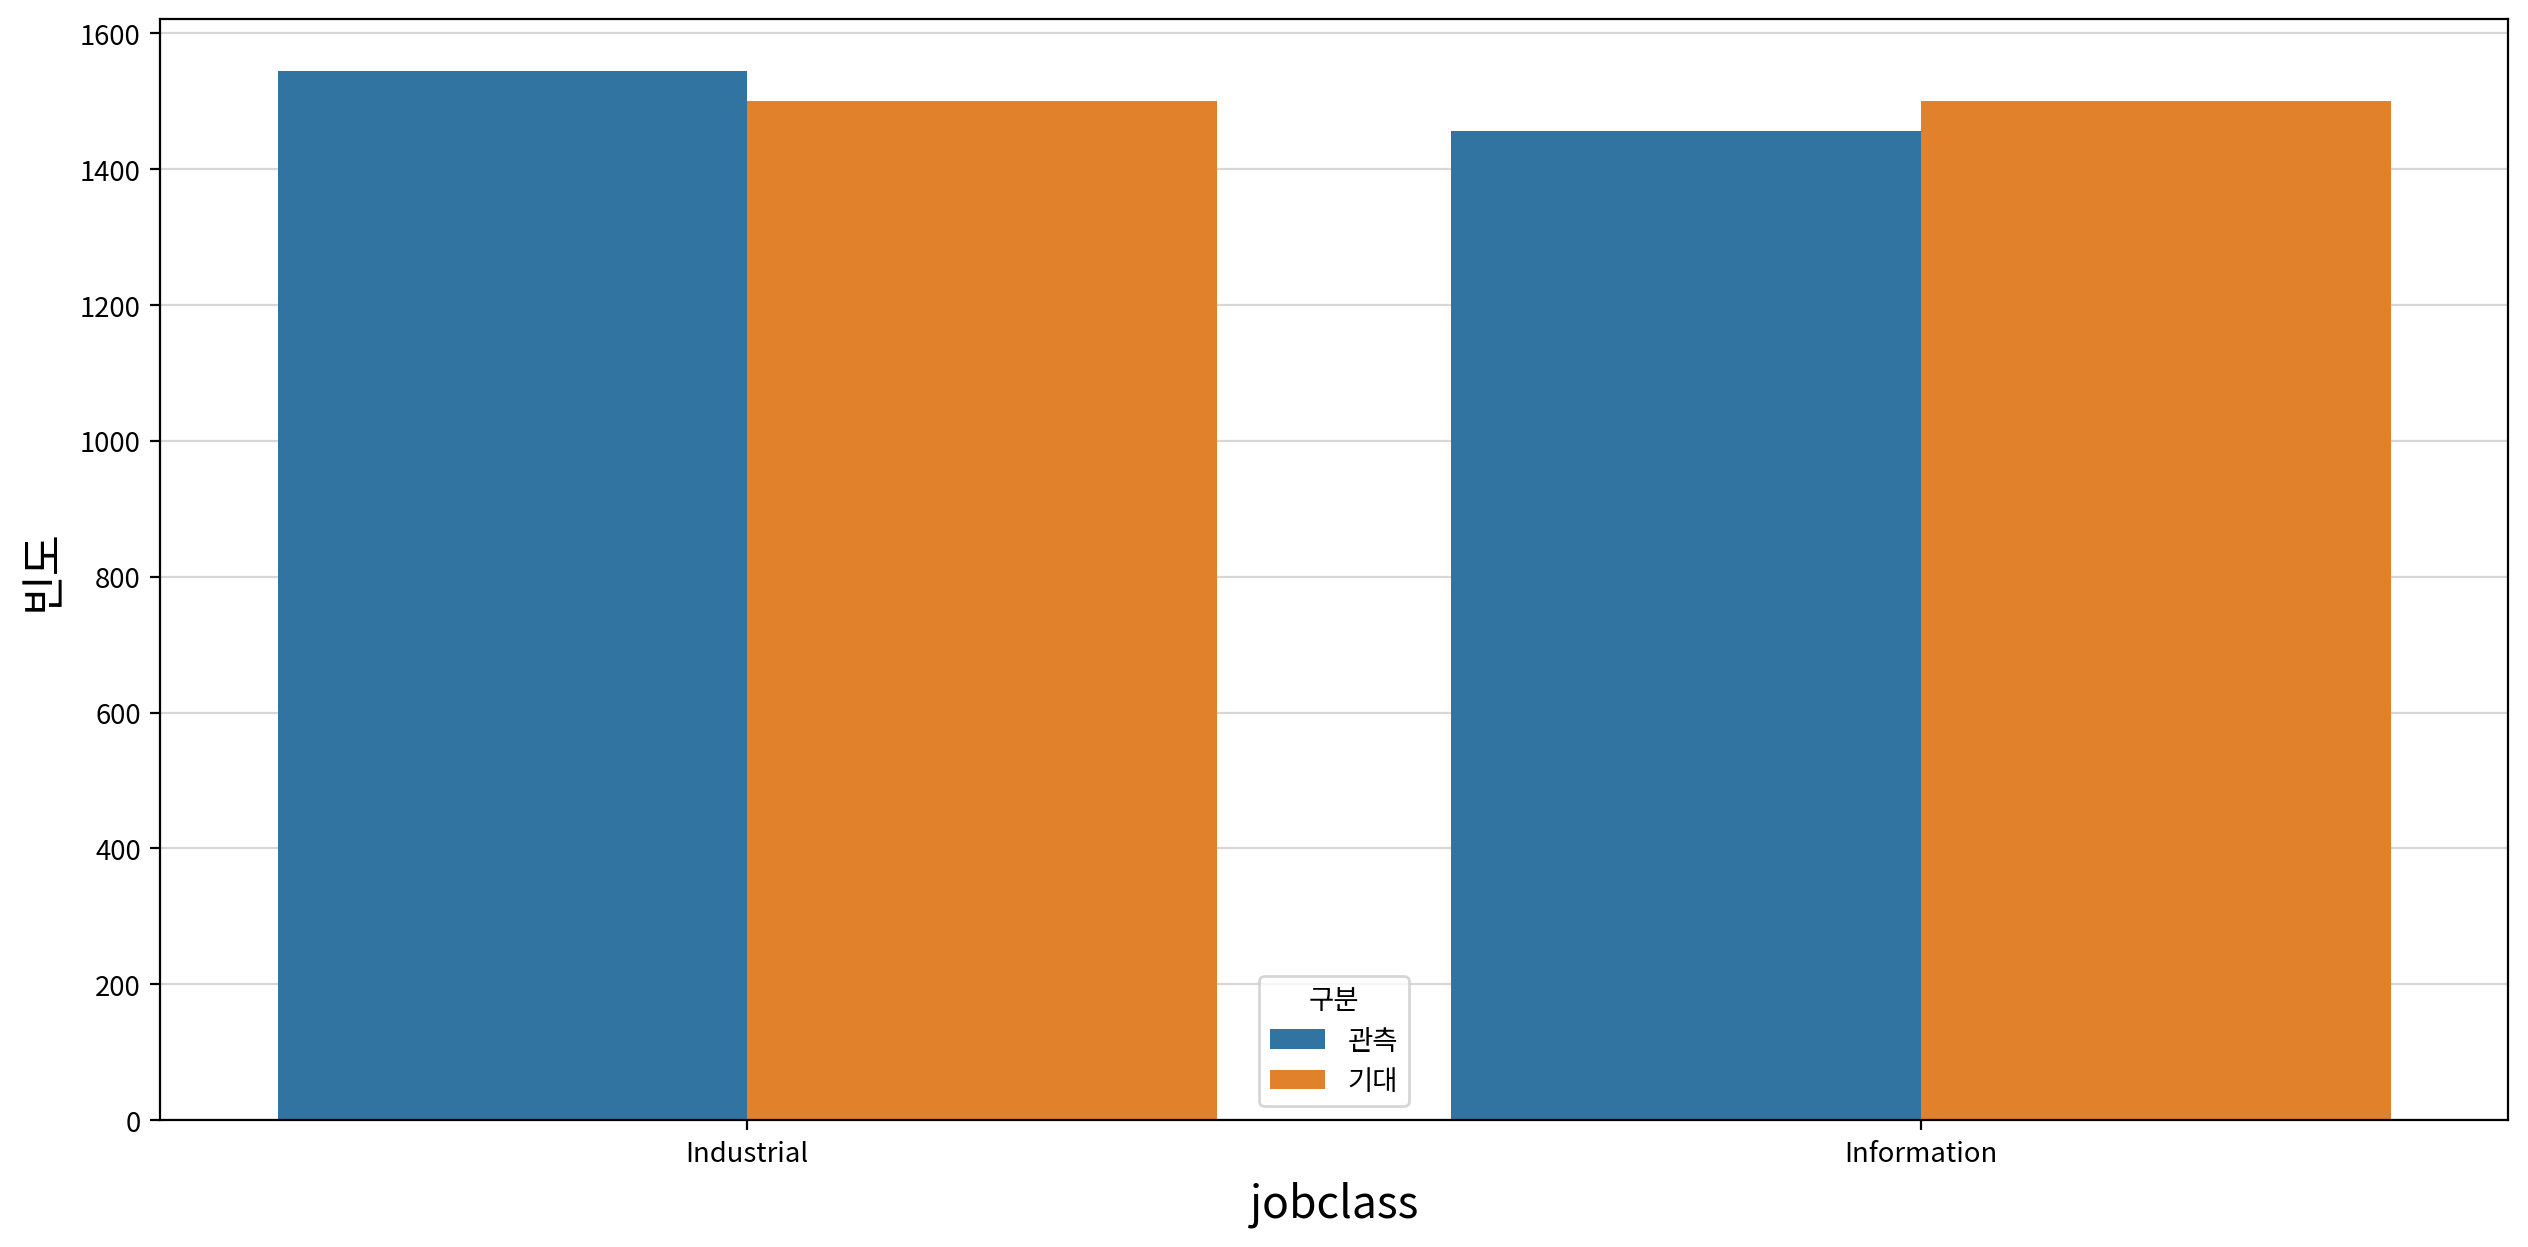

,chi2,dof,p-value,significant,effect(w),strength,min_expected,assumption
Chi-square goodness-of-fit,2.581,1,0.108,False,0.029,Negligible,1500.000,True


In [4]:
# 적합도 검정
my_stats.chi2_goodness_of_fit(df, 'jobclass')

- p-value = 0.108 > 0.05 이므로 귀무가설을 채택한다. 두 직군은 균등하게 분포한다고 볼 수 있다.

#### 문제 2. 교육을 더 받은 사람일수록 Information 직군에서 일하는지 아니면 교육수준과 직군은 무관한지?

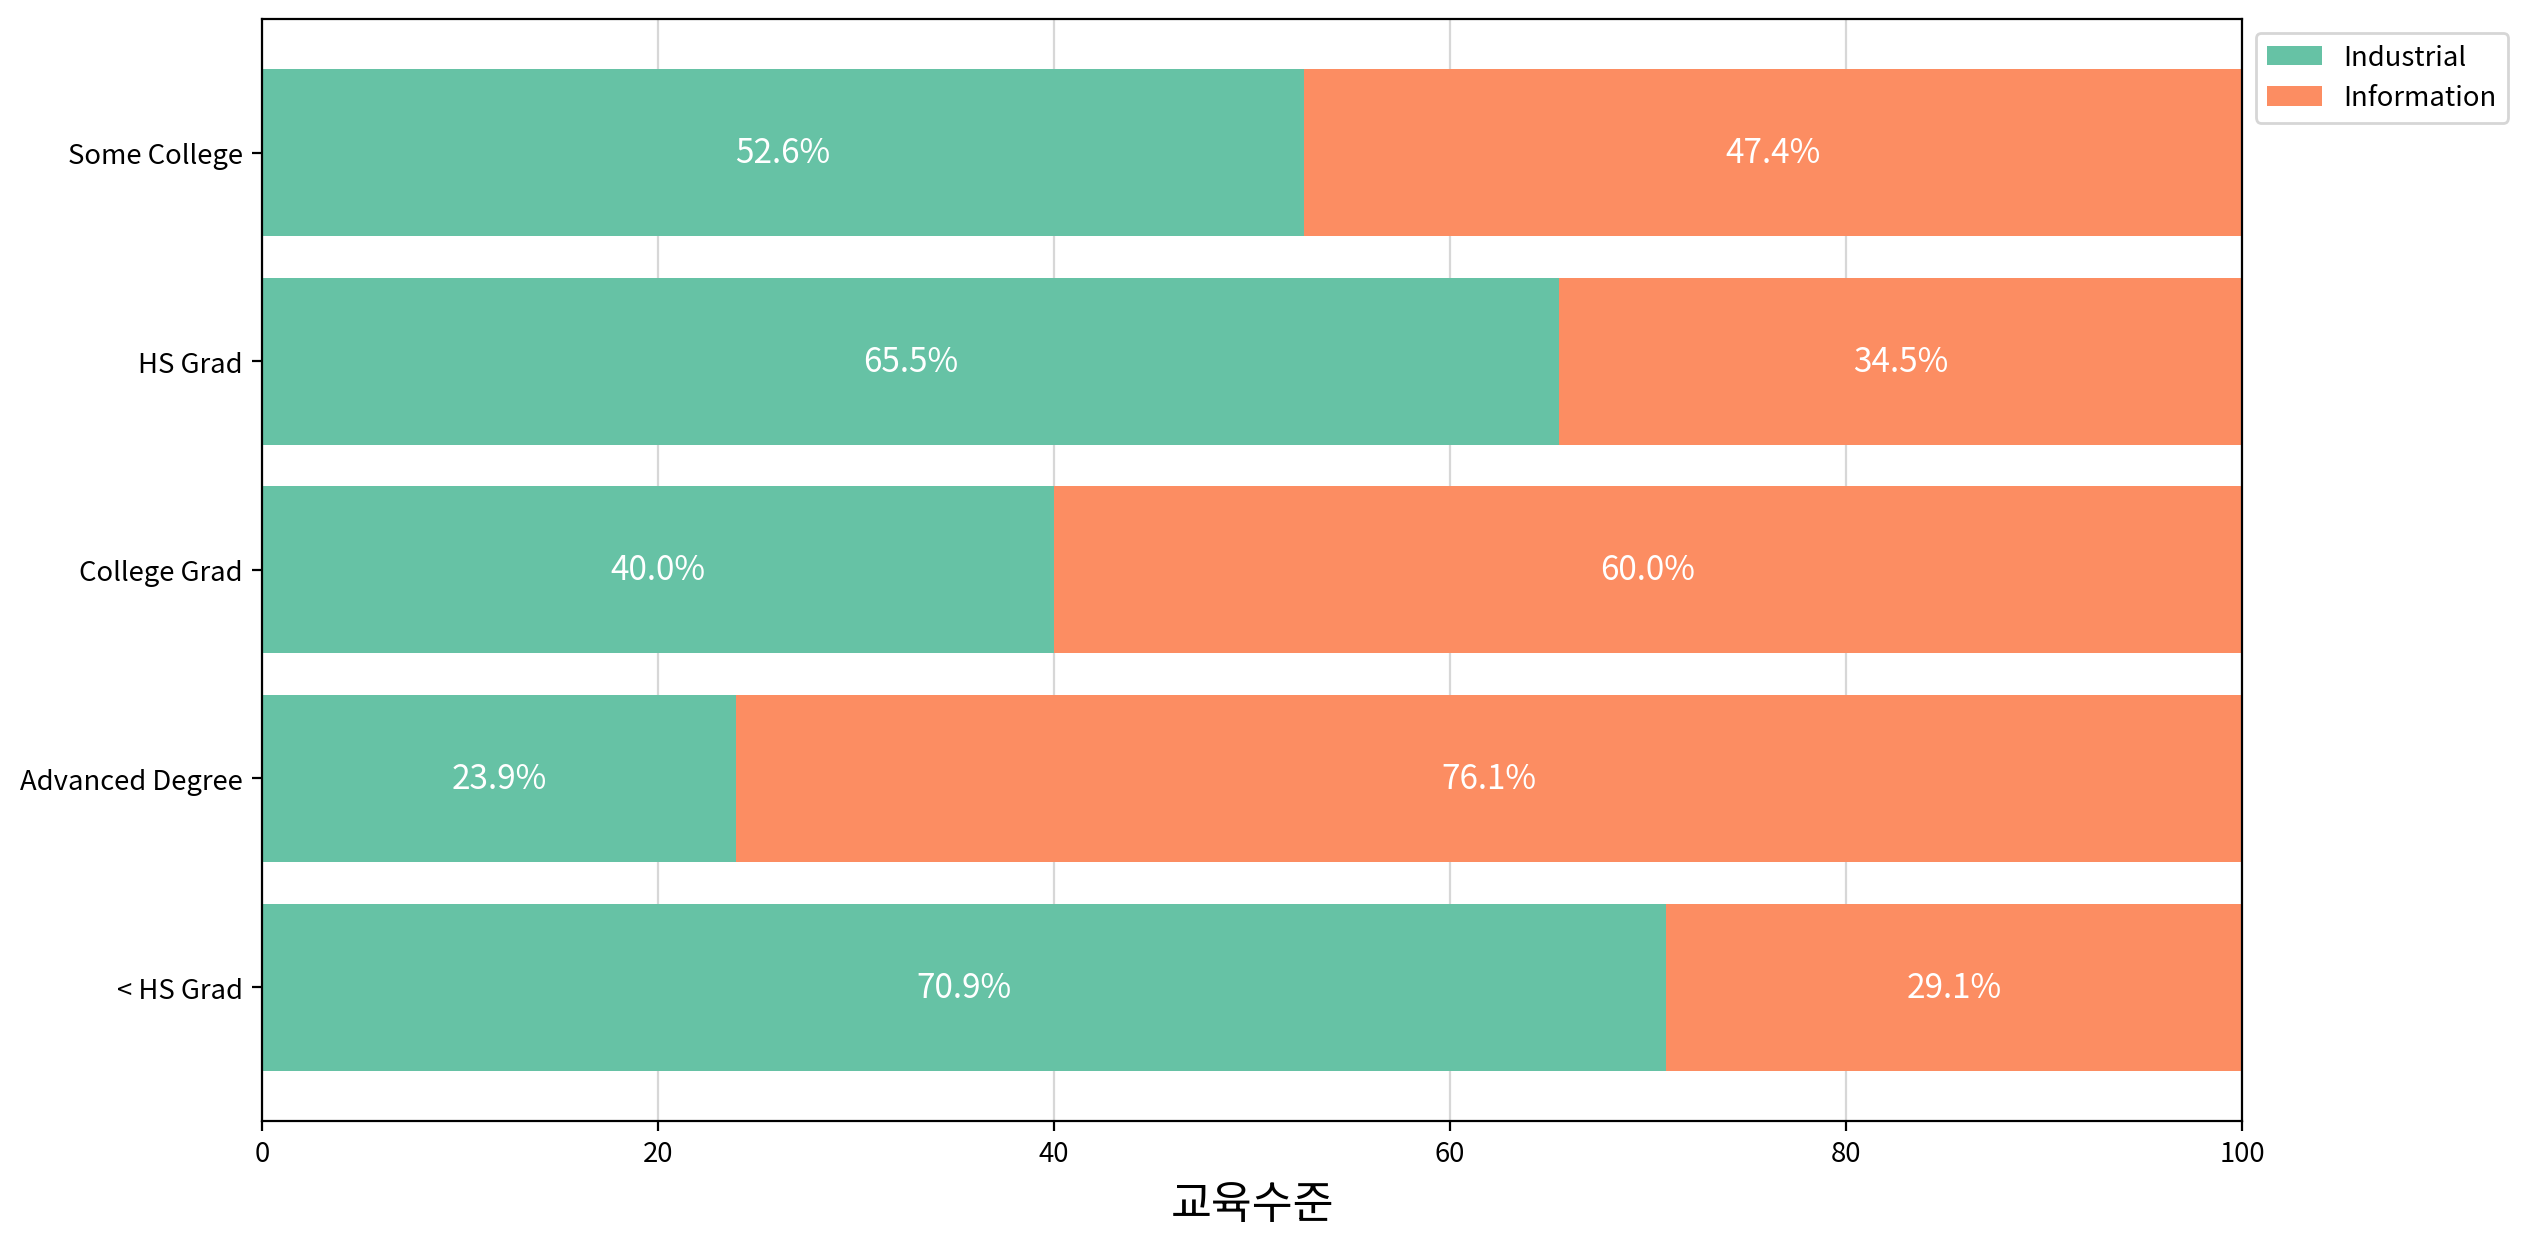

,,test,chi2,dof,p-value,significant,effect(v),strength,min_expected,assumption
row,col,,,,,,,,,
education,jobclass,Chi-square test of independence,282.643,4,0.000,True,0.307,Moderate,130.070,True


In [5]:
my_stats.chi2_independence(df, 'education', 'jobclass', orient='h', palette='Set2',
                           xlabel='교육수준', height=400)

- p-value = 0.000 < 0.05 이므로 교육수준과 직군은 무관하지 않고 통계적으로 유의한 관련이 있다고 볼 수 있다.
- 그래프를 보면 '< HS Grad'와 'HS Grad'는 Industrial 비율이 높고, 'College Grad'와 'Advanced Degree'는 Information 비율이 높다.
- 따라서 교육수준이 높을수록 Information 직군에서 일하는 경향이 있다고 해석할 수 있다. Cramer's V = 0.307로 관련성의 강도는 중간 수준이다.

#### 문제 3. 건강보험 미가입자를 줄이는 캠페인을 하려는데 가장 우선 지원해야할 교육수준 집단은?

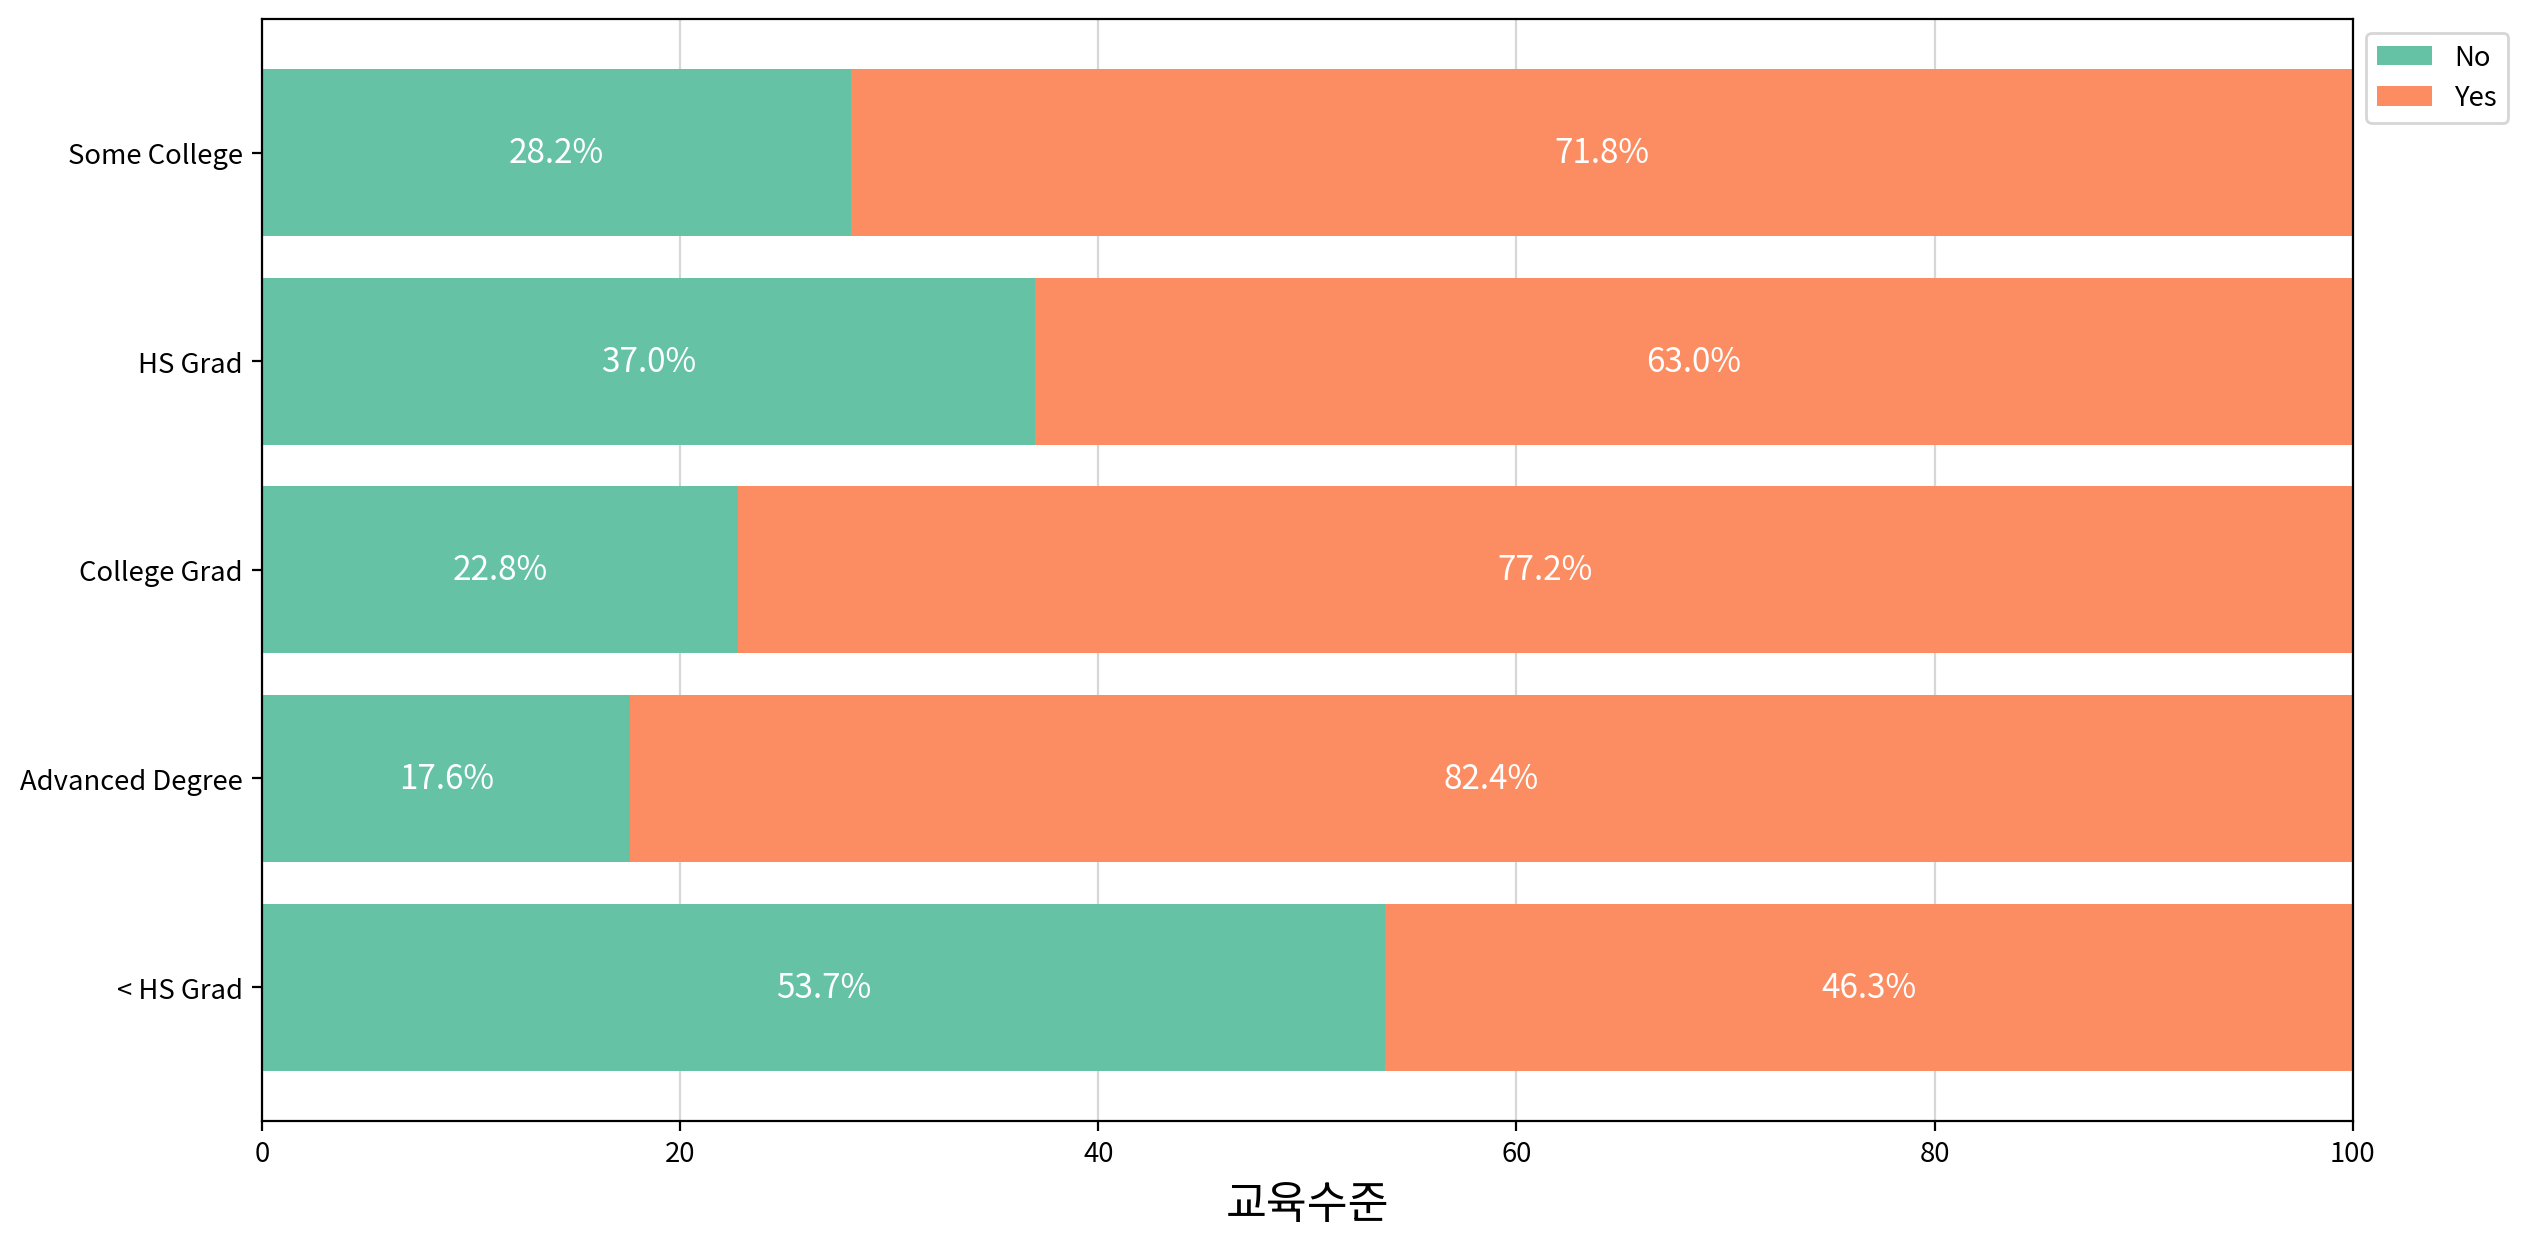

,,test,chi2,dof,p-value,significant,effect(v),strength,min_expected,assumption
row,col,,,,,,,,,
education,health_ins,Chi-square test of independence,141.635,4,0.000,True,0.217,Weak,81.920,True


In [6]:
my_stats.chi2_independence(df, 'education', 'health_ins', orient='h', palette='Set2',
                           xlabel='교육수준', height=400)

- 교육수준과 건강보험 가입 여부의 교차분석 결과, p-value = 0.000 < 0.05 교육수준과 건강보험 가입 여부는 통계적으로 유의한 관련이 있다. 다만 Cramer's V = 0.217로 관련성의 강도는 약한 수준이다.
- 교육수준별 미가입(No) 비율을 보면 '< HS Grad'가 53.7%로 가장 높으므로, 건강보험 미가입자를 줄이기 위한 캠페인에서는 '< HS Grad' 집단을 가장 우선 지원해야할 집단으로 선정하는 것이 적절하다.

#### 문제 4. Industrial 직군과 Information 직군 두 집단의 건강보험 가입 분포가 같은 지 비교

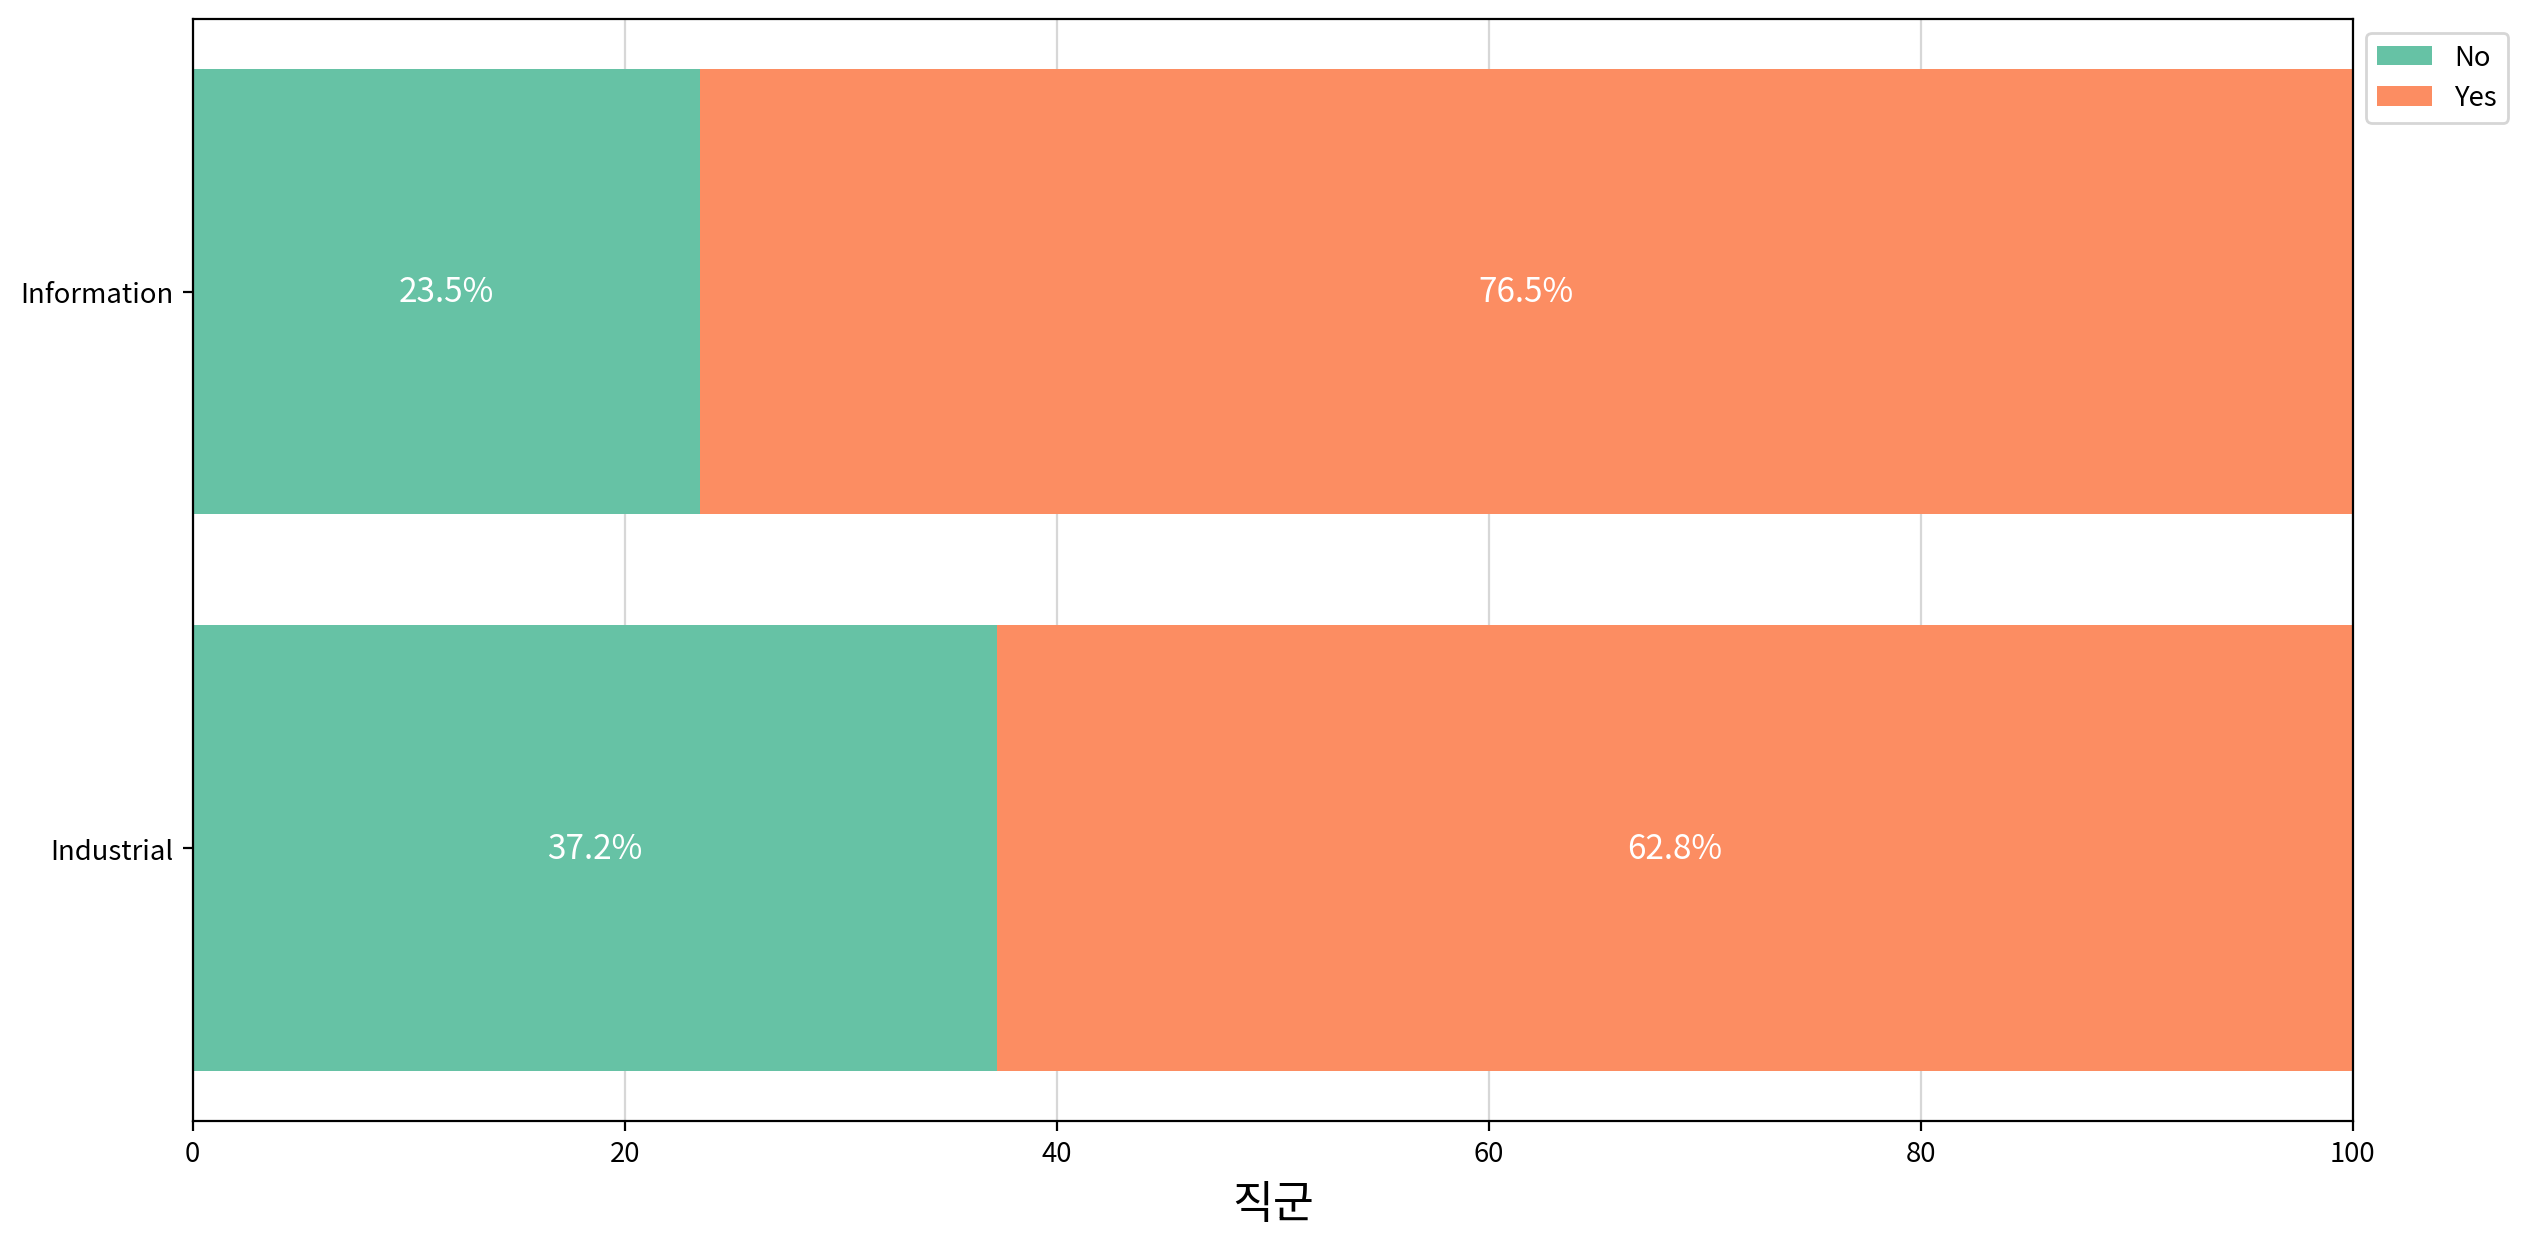

,,test,chi2,dof,p-value,significant,effect(v),strength,min_expected,assumption
row,col,,,,,,,,,
jobclass,health_ins,Chi-square test of independence,66.126,1,0.000,True,0.148,Weak,445.050,True


In [7]:
my_stats.chi2_independence(df, 'jobclass', 'health_ins', orient='h', palette='Set2',
                           xlabel='직군', height=400)

- 직군과 건강보험 가입 여부의 교차분석 결과, p-value = 0.000 < 0.05 직군과 건강보험 가입 여부는 통계적으로 유의한 관련이 있다. 
- 다만 Cramer's V = 0.148로 관련성의 강도는 약한 수준이다.
- 직군별 건강보험 가입(Yes) 비율을 보면 'Information'이 76.5%로 더 높은 것으로 나타났다.

#### 문제 5. 임금과 가장 강하게 연결된 범주형 뭔지 비교

In [8]:
q75 = df['wage'].quantile(0.75)

df['임금'] = '일반임금'
df.loc[df['wage'] >= q75, '임금'] = '고임금'

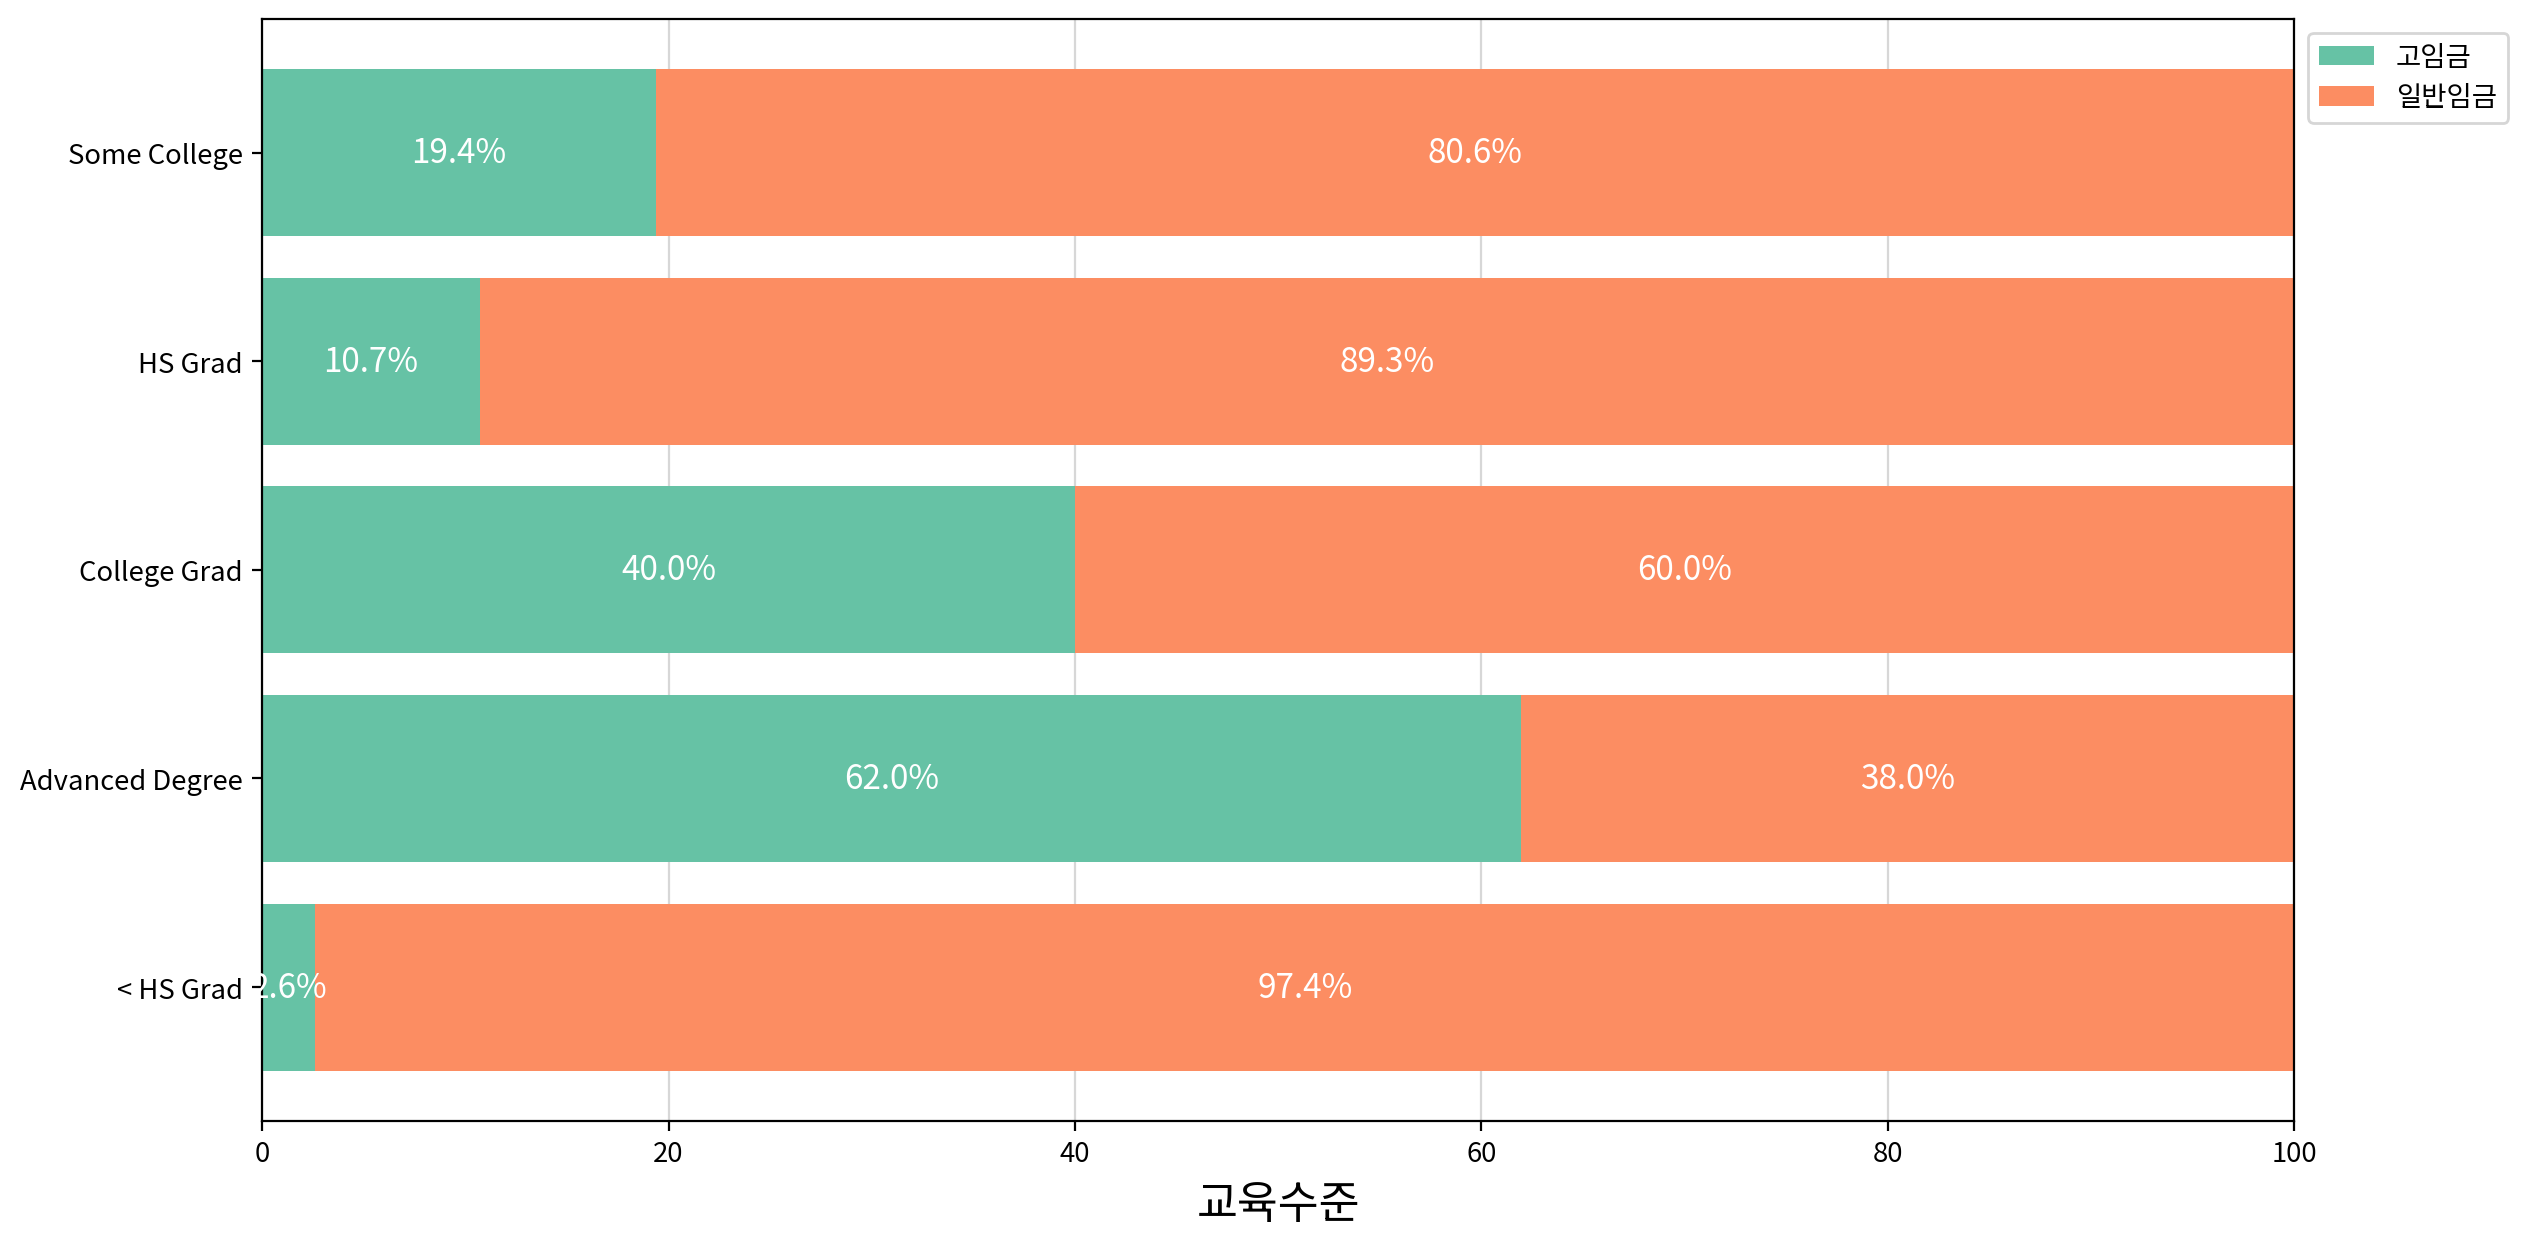

,,test,chi2,dof,p-value,significant,effect(v),strength,min_expected,assumption
row,col,,,,,,,,,
education,임금,Chi-square test of independence,567.564,4,0.000,True,0.435,Moderate,69.230,True


In [9]:
my_stats.chi2_independence(df, 'education', '임금', orient='h', palette='Set2',
                           xlabel='교육수준', height=400)

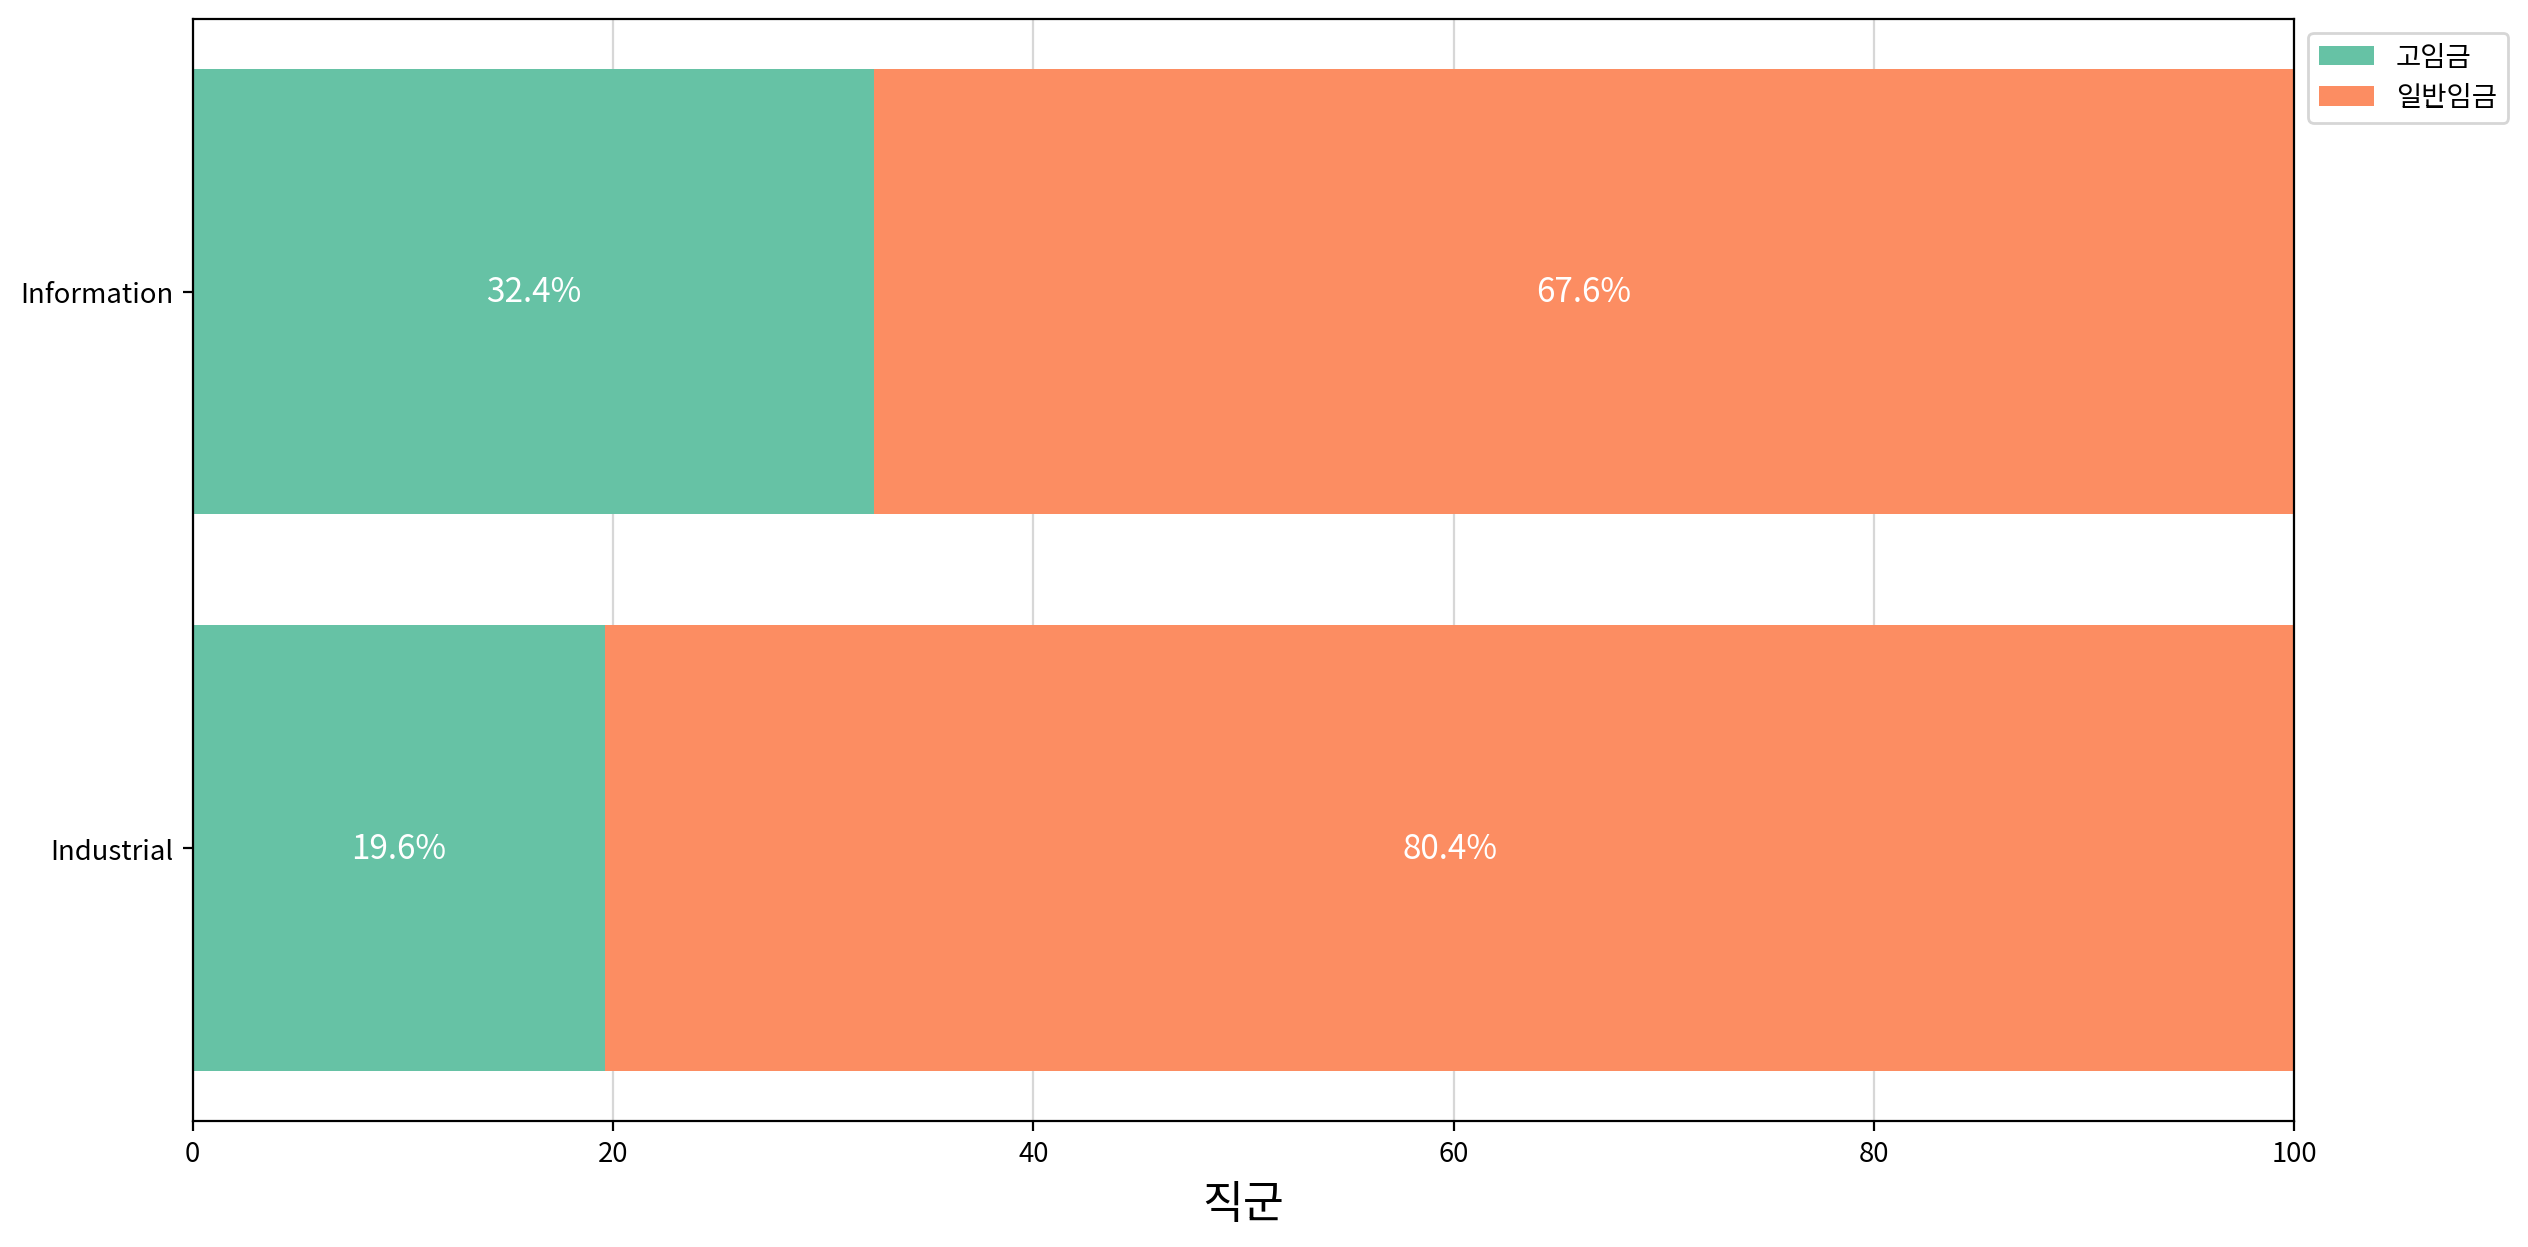

,,test,chi2,dof,p-value,significant,effect(v),strength,min_expected,assumption
row,col,,,,,,,,,
jobclass,임금,Chi-square test of independence,63.346,1,0.000,True,0.145,Weak,376.130,True


In [10]:
my_stats.chi2_independence(df, 'jobclass', '임금', orient='h', palette='Set2',
                           xlabel='직군', height=400)

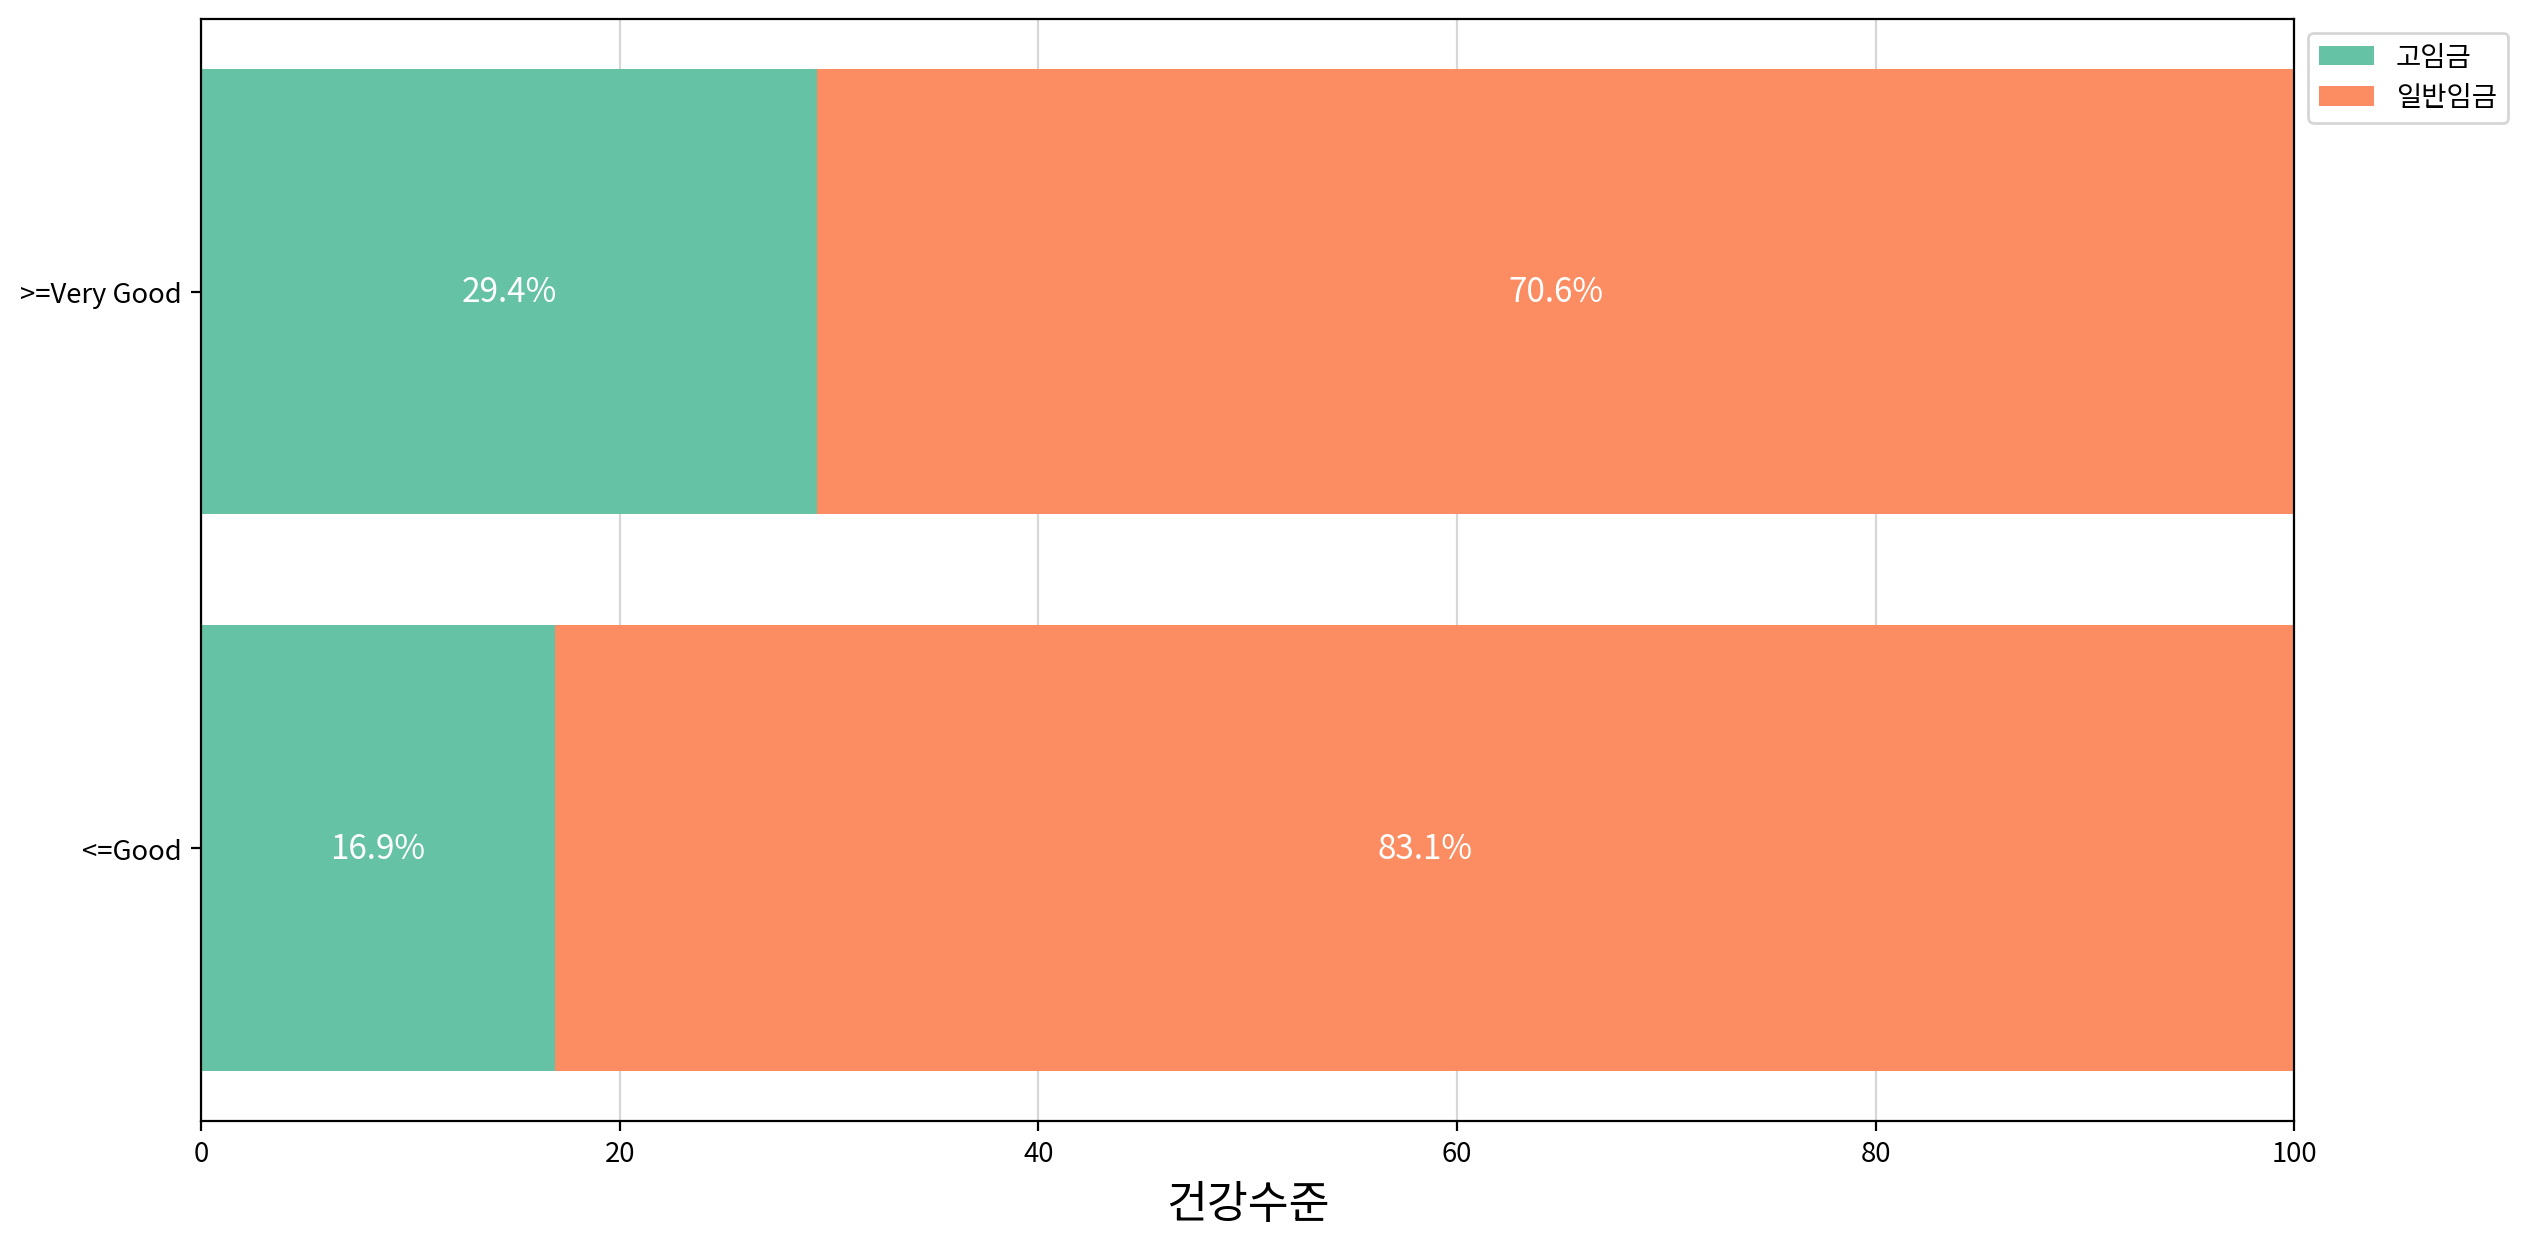

,,test,chi2,dof,p-value,significant,effect(v),strength,min_expected,assumption
row,col,,,,,,,,,
health,임금,Chi-square test of independence,49.404,1,0.000,True,0.128,Weak,221.650,True


In [11]:
my_stats.chi2_independence(df, 'health', '임금', orient='h', palette='Set2',
                           xlabel='건강수준', height=400)

- 임금과 education, jobclass, health의 관련성을 각각 카이제곱 독립성 검정으로 확인하였다.
- 세 변수 모두 p-value = 0.000 < 0.05로 나타나 임금과 통계적으로 유의한 관련이 있었다.

- 그 중 Cramer's V(effect(v)) 값은 education이 0.435로 가장 컸고, 관련성의 강도는 중간 수준(Moderate)으로 나타났다. jobclass는 0.145, health는 0.128로 모두 약한 수준(Weak)이었다.

- 따라서 임금(상위 25%를 고임금으로 구분)과 가장 강하게 연결된 범주형 변수는 education이다.